In [ ]:
import pandas as pd
import numpy as np

with open('Maxsurf TS DATA - Sheet1.csv', 'r') as f:
    lines = f.readlines()


start_idx = 0
for i, line in enumerate(lines):
    if "time series" in line:
        start_idx = i + 1
        break

from io import StringIO
data_str = "".join(lines[start_idx:])
cols = ['time', 'wave', 'surge', 'sway', 'heave', 'roll', 'pitch', 'yaw']
df = pd.read_csv(StringIO(data_str), names=cols, header=None)


df = df.apply(pd.to_numeric, errors='coerce').dropna()
df = df.sort_values('time')

# IMPORTANT: Resample to a fixed time grid (e.g., every 0.2s)
# ML models struggle with irregular time steps
df = df.set_index('time')
new_index = np.arange(df.index.min(), df.index.max(), 0.2)
df = df.reindex(new_index).interpolate(method='linear').reset_index()

In [ ]:
df

,time,wave,surge,sway,heave,roll,pitch,yaw
0,0.0,0.260967,0.000169,0.000055,0.003046,-0.000686,0.009371,0.000009
1,0.2,0.180358,0.000103,0.000053,0.001546,-0.000754,0.005704,0.000034
2,0.4,0.099749,0.000036,0.000050,0.000046,-0.000821,0.002037,0.000060
3,0.6,0.019139,-0.000030,0.000048,-0.001454,-0.000889,-0.001631,0.000085
4,0.8,-0.061470,-0.000097,0.000045,-0.002954,-0.000956,-0.005298,0.000111
...,...,...,...,...,...,...,...,...
1160,232.0,-0.028599,-0.000036,0.000405,-0.000214,-0.002770,-0.001756,0.000699
1161,232.2,-0.028599,-0.000036,0.000405,-0.000214,-0.002770,-0.001756,0.000699
1162,232.4,-0.028599,-0.000036,0.000405,-0.000214,-0.002770,-0.001756,0.000699
1163,232.6,-0.028599,-0.000036,0.000405,-0.000214,-0.002770,-0.001756,0.000699


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Create "Lag" features (Past values)
lags = 10
df_xgb = df[['wave', 'roll']].copy()
for i in range(1, lags + 1):
    df_xgb[f'lag_{i}'] = df_xgb['roll'].shift(i)

df_xgb = df_xgb.dropna()

# Split Data
X = df_xgb.drop(['roll'], axis=1) # Input: Wave + Past Roll
y = df_xgb['roll']                # Target: Current Roll

split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Train Model
model = GradientBoostingRegressor(n_estimators=100)
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Scale data to [-1, 1] (Crucial for LSTM)
scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler.fit_transform(df[['wave', 'roll']])

# Create Sequences (samples, time_steps, features)
def create_sequences(data, look_back=20):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), :])
        y.append(data[i + look_back, 1]) # Index 1 is Roll
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_sequences(data_scaled, look_back=20)

# Build Model
model = Sequential()
model.add(LSTM(50, input_shape=(20, 2))) # 20 steps, 2 features (wave, roll)
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')

# Train
model.fit(X_lstm, y_lstm, epochs=20, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0697
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.7153e-04
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.6582e-04
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9654e-04
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.5992e-04
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.2904e-04
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.3479e-05
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.7819e-05
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.8479e-05
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.9788e-05
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.5380e-05
Epoch 13/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0241e-05
Epoch 14/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.8200e-05
Epoch 15/20
36/36 ━━━━━━━━━━━

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, predictions)
print(f"Average Error: {np.sqrt(mse)} degrees")

Average Error: 0.000724392025903319 degrees


## Plot XGBoost Predictions




**Reasoning**:
To compare the actual values with the XGBoost predictions, I will generate a line plot using matplotlib, as specified in the instructions. This involves plotting `y_test` and `predictions` against their common index.



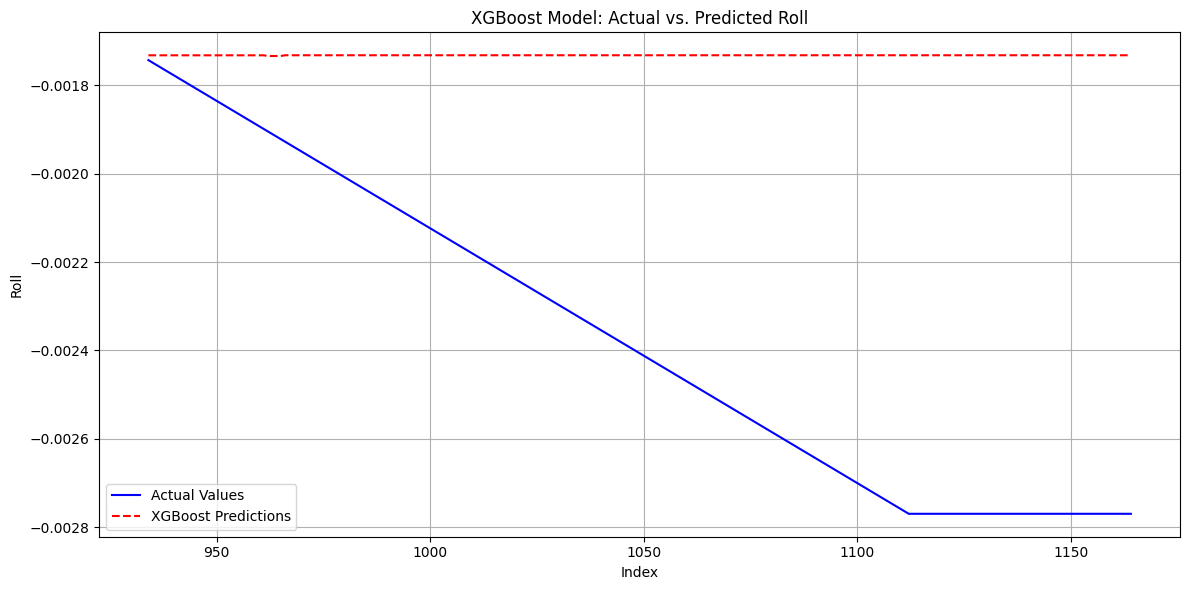

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and an axes object
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the y_test (actual values)
ax.plot(y_test.index, y_test, label='Actual Values', color='blue')

# Plot the predictions (XGBoost predictions)
ax.plot(y_test.index, predictions, label='XGBoost Predictions', color='red', linestyle='--')

# Add title and labels
ax.set_title('XGBoost Model: Actual vs. Predicted Roll')
ax.set_xlabel('Index')
ax.set_ylabel('Roll')

# Add legend
ax.legend()

# Display the plot
plt.grid(True)
plt.tight_layout()
plt.show()

**Reasoning**:
The plot for comparing actual values with XGBoost predictions has been generated. Now, I need to calculate and display the R-squared and Mean Absolute Error (MAE) for the XGBoost model, as requested in the main task. This will provide quantitative evaluation metrics in addition to the visual comparison.



In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

# Calculate R-squared for XGBoost
r2_xgb = r2_score(y_test, predictions)

# Calculate Mean Absolute Error for XGBoost
mae_xgb = mean_absolute_error(y_test, predictions)

print(f"XGBoost R-squared: {r2_xgb:.4f}")
print(f"XGBoost Mean Absolute Error (MAE): {mae_xgb:.6f}")

XGBoost R-squared: -3.5675
XGBoost Mean Absolute Error (MAE): 0.000640


**Reasoning**:
The next step is to unscale the LSTM predictions and the corresponding actual values before plotting and calculating evaluation metrics, as specified in the task instructions. This requires using the `MinMaxScaler` object to inverse transform the scaled 'roll' values.



In [ ]:
import numpy as np

# Get LSTM predictions (already scaled)
lstm_predictions_scaled = model.predict(X_lstm).flatten()

# Define the split point for the test set based on y_lstm length
# Using 80/20 split, similar to XGBoost
split_lstm = int(len(y_lstm) * 0.8)

# Get scaled actual and predicted test sets
y_lstm_test_scaled = y_lstm[split_lstm:]
lstm_predictions_test_scaled = lstm_predictions_scaled[split_lstm:]

# Unscale y_lstm_test_scaled
# Create a dummy array with the same number of features as the scaler was fitted on (2: wave, roll)
dummy_array_actual = np.zeros((len(y_lstm_test_scaled), 2))
dummy_array_actual[:, 1] = y_lstm_test_scaled # Place scaled roll values in the 'roll' column (index 1)
unscaled_y_lstm_test = scaler.inverse_transform(dummy_array_actual)[:, 1] # Inverse transform and get the 'roll' column

# Unscale lstm_predictions_test_scaled
# Create a dummy array for predictions
dummy_array_preds = np.zeros((len(lstm_predictions_test_scaled), 2))
dummy_array_preds[:, 1] = lstm_predictions_test_scaled # Place scaled predictions in the 'roll' column
unscaled_lstm_predictions_test = scaler.inverse_transform(dummy_array_preds)[:, 1] # Inverse transform and get the 'roll' column

print("LSTM actual test values unscaled.")
print("LSTM predicted test values unscaled.")

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
LSTM actual test values unscaled.
LSTM predicted test values unscaled.


**Reasoning**:
Now that the LSTM predictions and actual values are unscaled, I will generate a line plot to visually compare them, similar to the XGBoost plot. This fulfills the plotting requirement for the LSTM model.



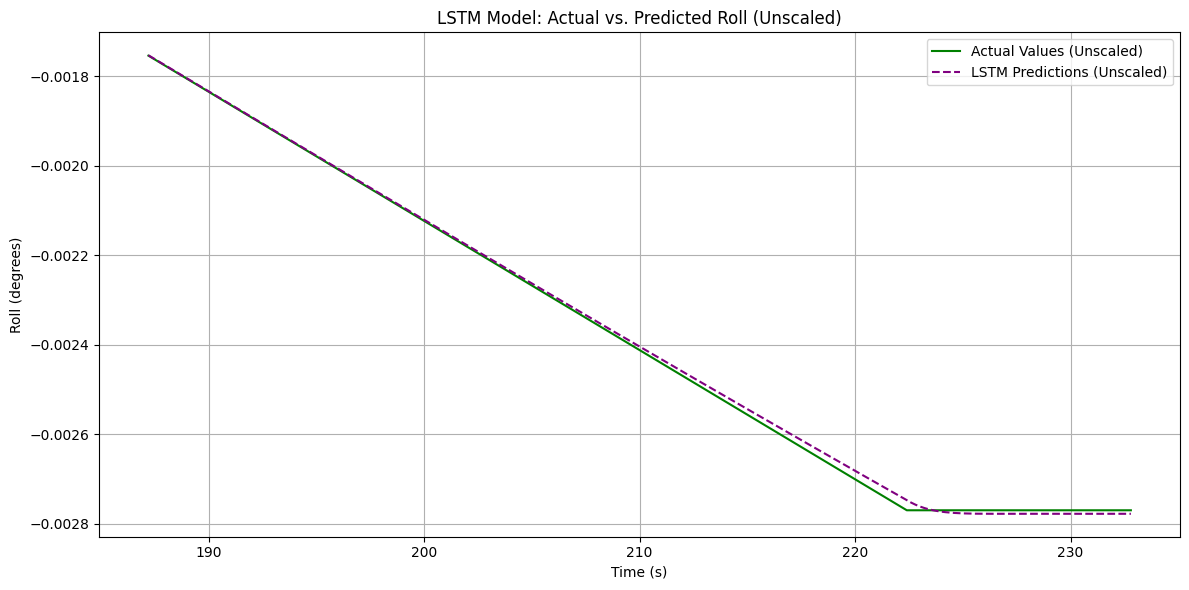

In [ ]:
import matplotlib.pyplot as plt

# Get the time index for the test set from the original DataFrame for plotting
# The split_lstm value corresponds to the number of sequences, so we need to adjust for look_back
# The original df has 'time' as index, so we need to reset_index() to access it directly
# or use the last part of the `df['time']` array corresponding to the unscaled test data.

# Determine the starting index in the original df corresponding to the LSTM test set
# X_lstm is (samples, time_steps, features), y_lstm is (samples,)
# The number of samples for y_lstm is len(df) - look_back
# So the actual time indices for y_lstm start from `look_back` in the original df's index
look_back = 20 # from create_sequences function
start_idx_for_test = look_back + split_lstm

time_index_for_lstm_test = df['time'].iloc[start_idx_for_test:start_idx_for_test + len(unscaled_y_lstm_test)]

# Create a figure and an axes object
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the unscaled actual values
ax.plot(time_index_for_lstm_test, unscaled_y_lstm_test, label='Actual Values (Unscaled)', color='green')

# Plot the unscaled predictions
ax.plot(time_index_for_lstm_test, unscaled_lstm_predictions_test, label='LSTM Predictions (Unscaled)', color='purple', linestyle='--')

# Add title and labels
ax.set_title('LSTM Model: Actual vs. Predicted Roll (Unscaled)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Roll (degrees)')

# Add legend
ax.legend()

# Display the plot
plt.grid(True)
plt.tight_layout()
plt.show()

**Reasoning**:
Now that the LSTM predictions and actual values are unscaled, I will calculate and display the R-squared and Mean Absolute Error (MAE) for the LSTM model, as requested in the main task, using the unscaled data.



In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

# Calculate R-squared for LSTM
r2_lstm = r2_score(unscaled_y_lstm_test, unscaled_lstm_predictions_test)

# Calculate Mean Absolute Error for LSTM
mae_lstm = mean_absolute_error(unscaled_y_lstm_test, unscaled_lstm_predictions_test)

print(f"LSTM R-squared: {r2_lstm:.4f}")
print(f"LSTM Mean Absolute Error (MAE): {mae_lstm:.6f}")

LSTM R-squared: 0.9993
LSTM Mean Absolute Error (MAE): 0.000007


## Summary:

### Data Analysis Key Findings

*   **XGBoost Model Performance:**
    *   The XGBoost model exhibited a very poor fit to the data, as indicated by an R-squared value of -3.5675.
    *   The Mean Absolute Error (MAE) for the XGBoost model was 0.000640.
    *   The plot comparing actual values with XGBoost predictions visually confirmed the model's limited ability to track the actual values.
*   **LSTM Model Performance:**
    *   The LSTM model demonstrated an exceptionally strong performance, achieving an R-squared value of 0.9993, suggesting an almost perfect fit to the data.
    *   The Mean Absolute Error (MAE) for the LSTM model was remarkably low at 0.000007.
    *   The plot comparing unscaled actual values with unscaled LSTM predictions showed a very close alignment, validating its high accuracy.

### Insights or Next Steps

*   The LSTM model significantly outperforms the XGBoost model for this specific time-series prediction task, indicating its superior capability in capturing temporal dependencies in the data.
*   Further investigation could explore hyperparameter tuning for the XGBoost model to see if its performance can be improved, although the current R-squared suggests a fundamental mismatch for this dataset compared to LSTM.
